# EDA K Means

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
import pickle
from sklearn.model_selection import GridSearchCV, train_test_split

## Definición del problema

>### Sistema de agrupación de casas
>Queremos ser capaces de clasificar casas según su la región en la que se encuentren y del ingreso medio. Para ello, utilizaremos el famoso conjunto de datos California Housing. Se construyó utilizando los datos del censo de California de 1990. Contiene una fila por grupo de bloques censales. Un grupo de bloques es la unidad geográfica más pequeña para la que se publican datos del censo de USA.

## Recopilación de datos

In [23]:
df = pd.read_csv('/workspaces/adamcn10-intro-ml/data/processed/housing.csv')
df.drop(['HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'MedHouseVal'], axis=1, inplace=True)
df

,MedInc,Latitude,Longitude
0,8.3252,37.88,-122.23
1,8.3014,37.86,-122.22
2,7.2574,37.85,-122.24
3,5.6431,37.85,-122.25
4,3.8462,37.85,-122.25
...,...,...,...
20635,1.5603,39.48,-121.09
20636,2.5568,39.49,-121.21
20637,1.7000,39.43,-121.22
20638,1.8672,39.43,-121.32


>Como marca el enunciado del proyecto, cargo los datos y me quedo solo con las columnas MedInc, Latitude y Longitude

## Análisis descriptivo

In [21]:
df.shape

(20640, 3)

>Vemos que se trata de un conjunto de datos de 20640 filas con 9 columnas cada una.

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   MedInc     20640 non-null  float64
 1   Latitude   20640 non-null  float64
 2   Longitude  20640 non-null  float64
dtypes: float64(3)
memory usage: 483.9 KB


>Ninguna de esta columnas tiene valores nulos y son todos valores numéricos de coma flotante (números con decimales)

In [24]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
Latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
Longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100


>Información estadística de los datos

In [25]:
df.nunique()

MedInc       12928
Latitude       862
Longitude      844
dtype: int64

>Vemos los valores únicos de cada una de las columnas

## Limpieza de datos

### Eliminar duplicados

In [26]:
df.duplicated().sum()

np.int64(5)

>Vemos 5 filas duplicadas en los datos, no los eliminare porque analizando con todas las variables se puede ver que son viviendas distintas con coincidencia en estos datos

### Eliminar información irrelevante

>No considero que tengamos información irrelevante más que la que hemos eliminado ya al inicio del proyecto, que eran las columnas 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup' y 'MedHouseVal'

## Análisis de Variables

### Análisis de Variables Univariante

array([[<Axes: title={'center': 'MedInc'}>,
        <Axes: title={'center': 'Latitude'}>],
       [<Axes: title={'center': 'Longitude'}>, <Axes: >]], dtype=object)

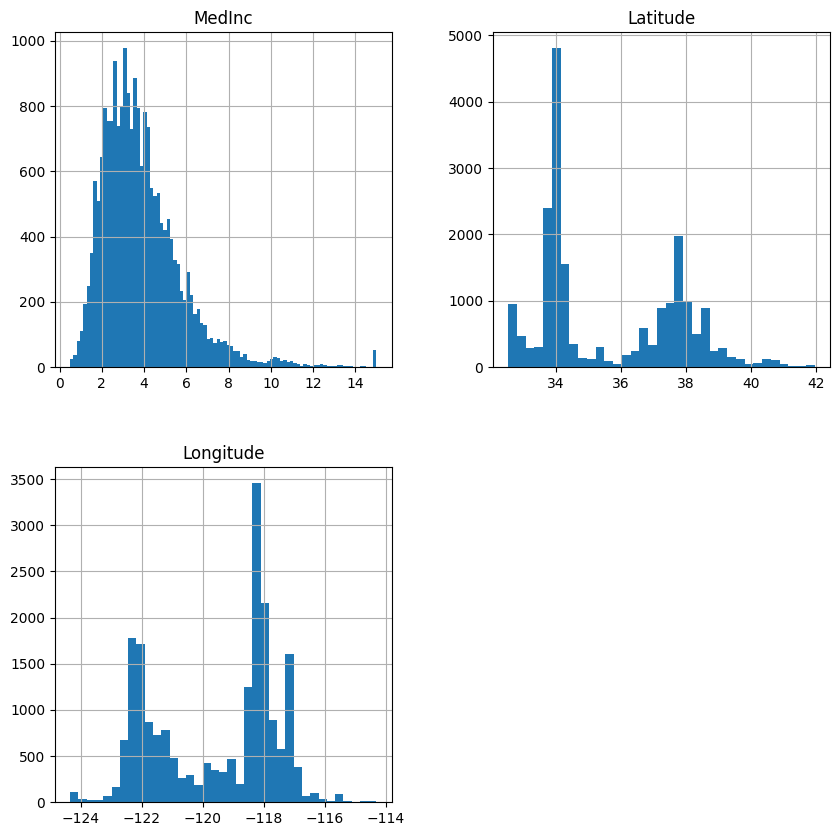

In [30]:
df.hist(figsize=[10, 10], bins='auto')

>Vemos de que manera están repartidos los datos en cada una de las columnas

<function matplotlib.pyplot.show(close=None, block=None)>

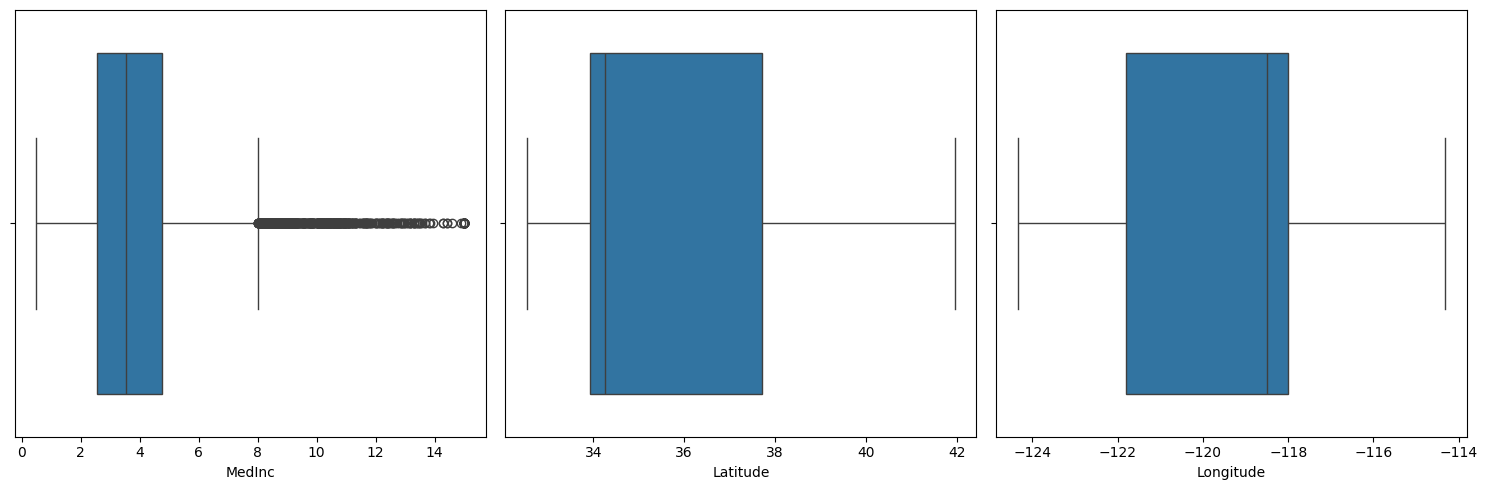

In [32]:
fig, axis = plt.subplots(1, 3, figsize=(15,5))

sns.boxplot(ax=axis[0], data=df, x="MedInc")
sns.boxplot(ax=axis[1], data=df, x="Latitude")
sns.boxplot(ax=axis[2], data=df, x="Longitude")

plt.tight_layout()
plt.show

>Vemos graficas de caja de cada una de las columnas para ver como están organizados los datos y si estos tienen outliers, en este caso el únco con utliers es el ingreso medio

### Análisis de Variables Multivariante

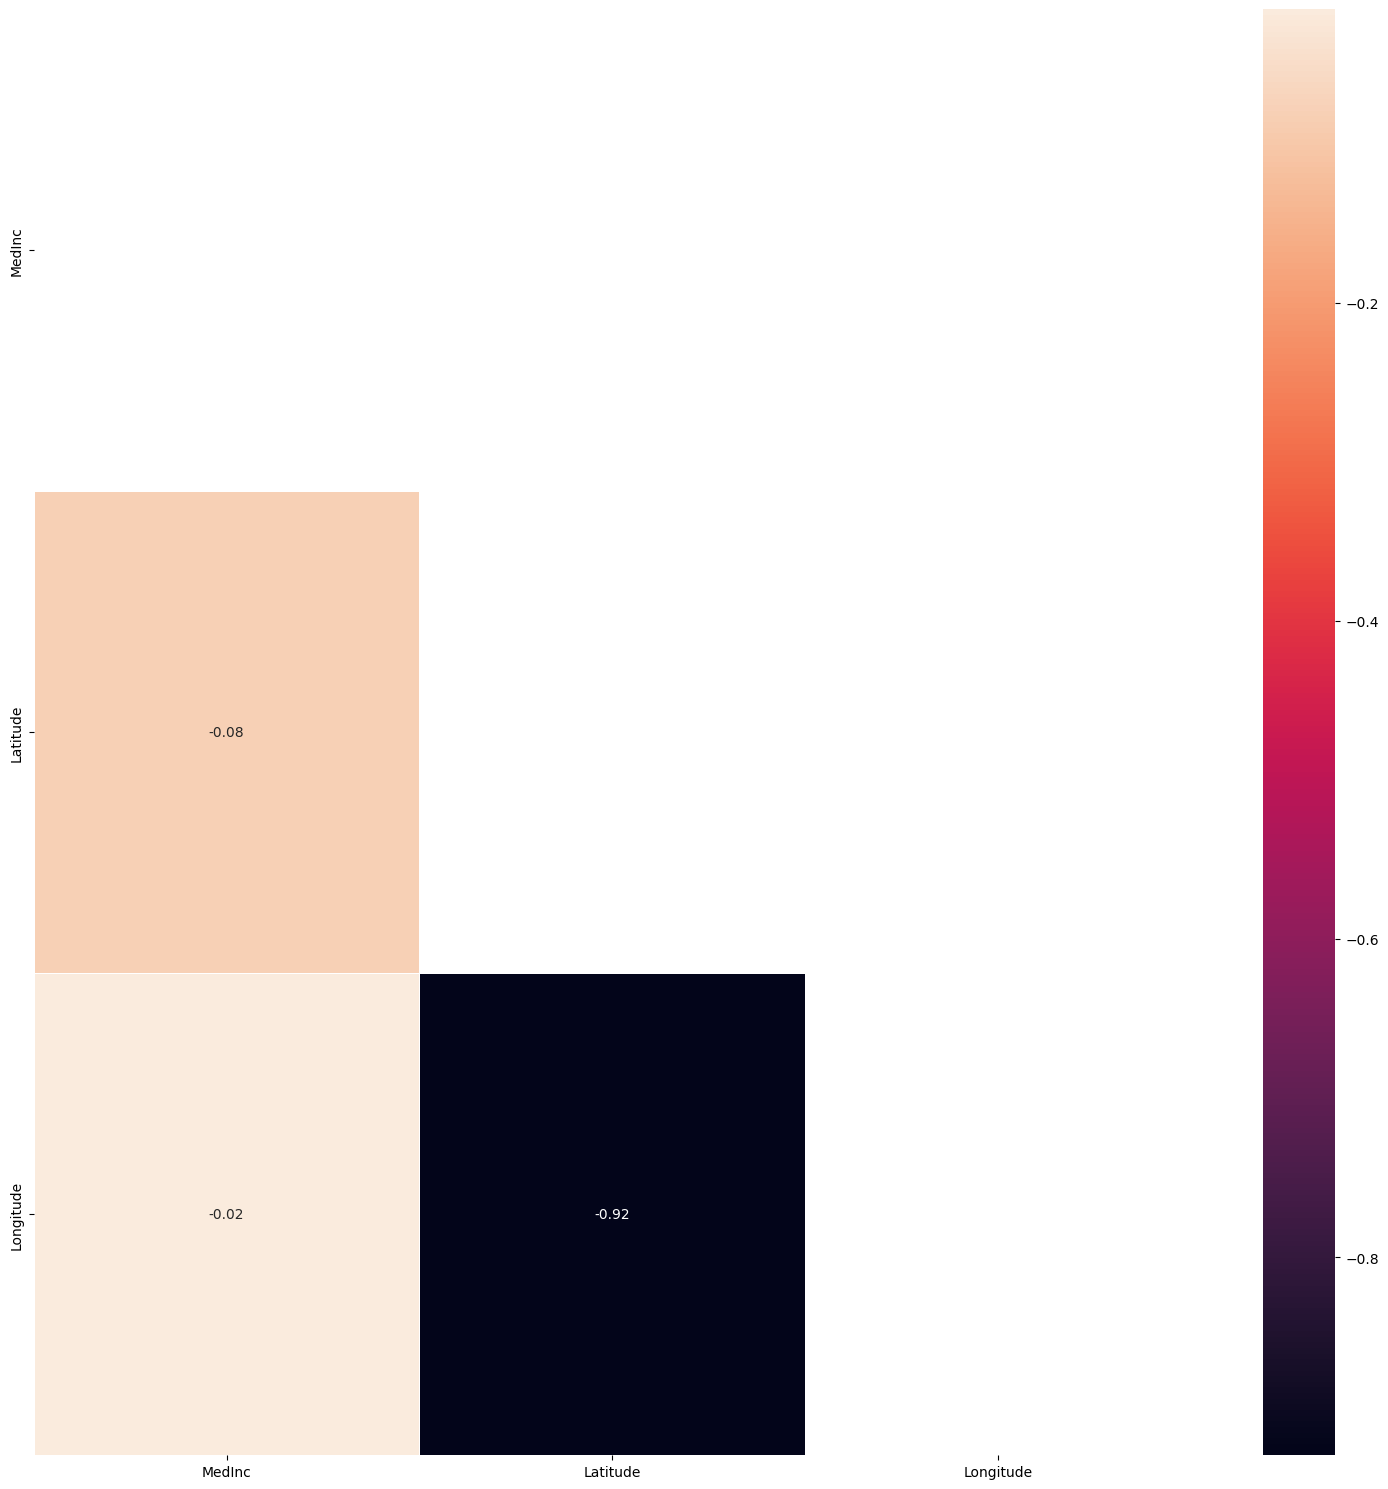

In [33]:
corr = df[['MedInc', 'Latitude', 'Longitude']].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, axis = plt.subplots(figsize=(15, 15))
sns.heatmap(corr, mask=mask, annot=True, linewidths=0.5, fmt=".2f")

plt.tight_layout()
plt.show()

>Vemos las correlaciones generales entre los datos dos a dos, donde podemos ver una única correlacion reelevante y esta es entre longitud y latitud. 

## Ingeniería de características

### Outliers

>Como hemos visto antes la única columna con valores atípicos es MedInc, pero no los trataremos ya que se puede observar que es una especie de cola alargada en cuanto a valores superiores y pese haber muchos valores parecen estar estructurados de manera continua.

### Faltantes

In [34]:
df.isnull().sum().sort_values(ascending=False)

MedInc       0
Latitude     0
Longitude    0
dtype: int64

>No vemos ningún valor nulo

### Inferencia de nuevas características

>No considero que a partir de los datos que tenemos debamos o podamos crear nuevas columnas

## Split

>El único paso del split que podemos hacer es asignar a X el conjunto completo de datos ya que no hay variable objetivo aún

In [35]:
X = df

## Scaling & Encoding

### Encoding

>Al ser todo datos númericos no hace falta ningun tipo de encoding.

### Scaling

>Utilizaré para ello RobustScaler ya que pese a tener solo una variable con outliers, esta contiene bastantes datos atípicos

In [38]:
robust_scaler = RobustScaler()

robust_scaler_train = robust_scaler.fit_transform(X)

X = pd.DataFrame(robust_scaler_train, 
                             columns=X.columns,
                             index=X.index)

X

,MedInc,Latitude,Longitude
0,2.197582,0.957672,-0.986807
1,2.186664,0.952381,-0.984169
2,1.707732,0.949735,-0.989446
3,0.967177,0.949735,-0.992084
4,0.142854,0.949735,-0.992084
...,...,...,...
20635,-0.905796,1.380952,-0.686016
20636,-0.448655,1.383598,-0.717678
20637,-0.841709,1.367725,-0.720317
20638,-0.765007,1.367725,-0.746702


## Guardado de datos procesados y Scalers

In [39]:
with open('/workspaces/adamcn10-intro-ml/models/k-mean-robust-scaler.pkl', 'wb') as file:
    pickle.dump(robust_scaler, file)

with open('/workspaces/adamcn10-intro-ml/data/processed/k-mean-X.pkl', 'wb') as file:
    pickle.dump(X, file)  